<a href="https://colab.research.google.com/github/JasminAcostaMendez26/Estad-stica-Verano/blob/main/Problemario_5_parte_2_EXAMEN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EJERCICIO 14.1

Ejercicio
14.1 Se realizó un experimento para estudiar los efectos de la temperatura y el tipo de horno sobre la vida
de un componente en particular. En el experimento se
utilizaron 4 tipos de horno y 3 niveles de temperatura.
Se asignaron 24 piezas al azar, 2 para cada combinación de tratamientos y se registraron los siguientes resultados.

### Horno

| Temperatura (°F) | O1  | O2  | O3  | O4  |
|------------------|-----|-----|-----|-----|
| 500              | 227 | 214 | 225 | 260 |
|                  | 221 | 259 | 236 | 229 |
| 550              | 187 | 181 | 232 | 246 |
|                  | 208 | 179 | 198 | 273 |
| 600              | 174 | 198 | 178 | 206 |
|                  | 202 | 194 | 213 | 219 |



A un nivel de signifi cancia de 0.05 pruebe las hipótesis
de que
 a) las diferentes temperaturas no tienen efecto en la
vida del componente;
 b) los diferentes hornos no tienen efecto en la vida
del componente;
 c) no hay interacción entre el tipo de horno y la temperatura.

In [ ]:
import pandas as pd
from io import StringIO

data = '''
temperatura,horno,respuesta
500,O1,227
500,O1,221
500,O2,214
500,O2,259
500,O3,225
500,O3,236
500,O4,260
500,O4,229
550,O1,187
550,O1,208
550,O2,181
550,O2,179
550,O3,232
550,O3,198
550,O4,246
550,O4,273
600,O1,174
600,O1,202
600,O2,198
600,O2,194
600,O3,178
600,O3,213
600,O4,206
600,O4,219
'''

df = pd.read_csv(StringIO(data))
df


,temperatura,horno,respuesta
0,500,O1,227
1,500,O1,221
2,500,O2,214
3,500,O2,259
4,500,O3,225
5,500,O3,236
6,500,O4,260
7,500,O4,229
8,550,O1,187
9,550,O1,208


# Sección nueva

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'respuesta ~ C(temperatura) * C(horno)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova



,sum_sq,df,F,PR(>F)
C(temperatura),5194.083333,2.0,8.129516,0.005863
C(horno),4963.125000,3.0,5.178688,0.015885
C(temperatura):C(horno),3126.250000,6.0,1.631016,0.221520
Residual,3833.500000,12.0,NaN,NaN


valor-p (Shapiro) = 0.5088993359835863
Los residuos siguen una distribución normal


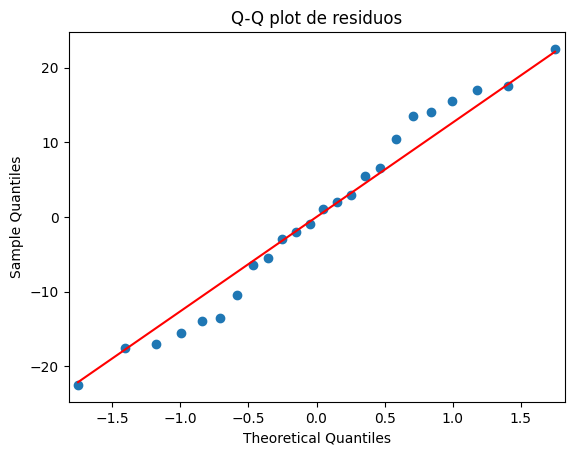

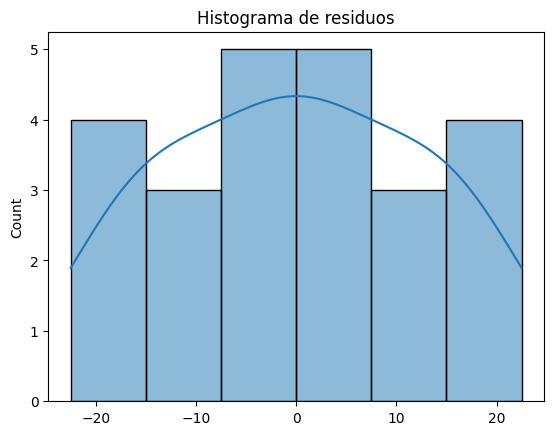

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")
if valor_p_sh > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['temperatura'] == 500]['respuesta']
grupo2 = df[df['temperatura'] == 550]['respuesta']
grupo3 = df[df['temperatura'] == 600]['respuesta']


stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.11268337626251641


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   500    550  -20.875   0.21 -50.9046  9.1546  False
   500    600  -35.875 0.0175 -65.9046 -5.8454   True
   550    600    -15.0 0.4331 -45.0296 15.0296  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

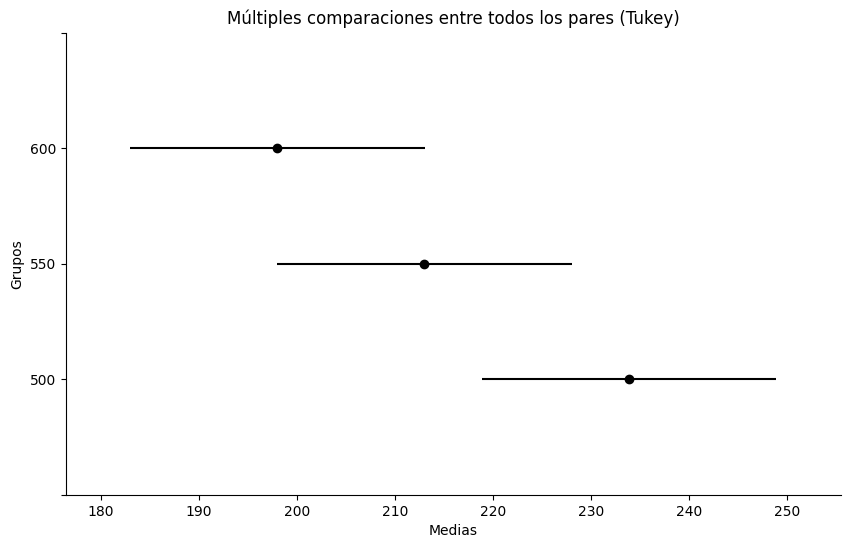

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['respuesta'], groups=df['temperatura'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

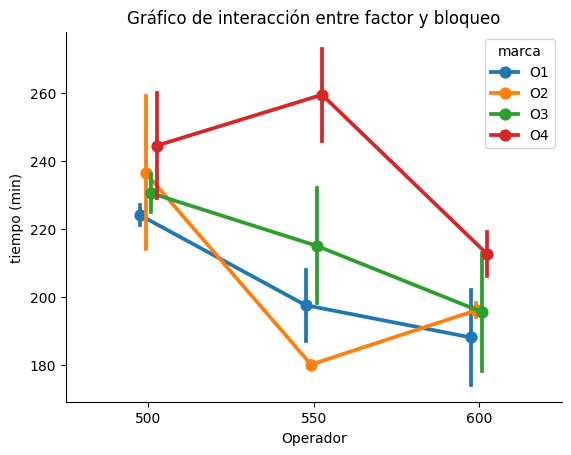

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="temperatura", y="respuesta", hue="horno", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="marca")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

## #EJERCICIO 14.2

Ejercicio 14.2 El Departamento de Nutrición Humana y
Alimentos del Virginia Tech realizó un estudio titulado
Vitamin C Retention in Reconstituted Frozen Orange
Juice sobre la estabilidad de la vitamina C en el concentrado de jugo de naranja congelado reconstituido y
almacenado en un refrigerador durante un periodo de
hasta una semana. Se probaron 3 tipos de concentrado
de jugo de naranja congelado en 3 periodos distintos,
los cuales se refi eren al número de días transcurridos
desde que se mezcló el jugo hasta que se probó. Se registraron los resultados en miligramos de ácido ascórbico por litro. Utilice un nivel de signifi cancia de
0.05 para probar las hipótesis de que

 a) no hay diferencias en el contenido de ácido ascórbico entre las diferentes marcas de concentrado de
jugo de naranja;

 b) no existen diferencias en el contenido de ácido ascórbico para distintos periodos;

 c) no hay interacción entre las marcas de concentrado de jugo de naranja y el número de días transcurridos desde que el jugo se mezcló hasta que se
probó.

### Tiempo (días)

| Marca         | Dato 1 | Dato 2 | Dato 3 | Dato 4 | Dato 5 | Dato 6 |
|---------------|--------|--------|--------|--------|--------|--------|
| Richfood      | 52.6   | 54.2   | 49.4   | 49.2   | 42.7   | 48.8   |
|               | 49.8   | 46.5   | 42.8   | 53.2   | 40.4   | 47.6   |
| Sealed-Sweet  | 56.0   | 48.0   | 48.8   | 44.0   | 49.2   | 44.0   |
|               | 49.6   | 48.4   | 44.0   | 42.4   | 42.0   | 43.2   |
| Minute Maid   | 52.5   | 52.0   | 48.0   | 47.0   | 48.5   | 43.3   |
|               | 51.8   | 53.6   | 48.2   | 49.6   | 45.2   | 47.6   |


In [ ]:
import pandas as pd
from io import StringIO

data = '''
marca,dia,medicion
Richfood,Día 0 - 1,52.6
Richfood,Día 0 - 1,49.8
Richfood,Día 0 - 2,54.2
Richfood,Día 0 - 2,46.5
Richfood,Día 3 - 1,49.4
Richfood,Día 3 - 1,42.8
Richfood,Día 3 - 2,49.2
Richfood,Día 3 - 2,53.2
Richfood,Día 7 - 1,42.7
Richfood,Día 7 - 1,40.4
Richfood,Día 7 - 2,48.8
Richfood,Día 7 - 2,47.6
Sealed_Sweet,Día 0 - 1,56.0
Sealed_Sweet,Día 0 - 1,49.6
Sealed_Sweet,Día 0 - 2,48.0
Sealed_Sweet,Día 0 - 2,48.4
Sealed_Sweet,Día 3 - 1,48.8
Sealed_Sweet,Día 3 - 1,44.0
Sealed_Sweet,Día 3 - 2,44.0
Sealed_Sweet,Día 3 - 2,42.4
Sealed_Sweet,Día 7 - 1,49.2
Sealed_Sweet,Día 7 - 1,42.0
Sealed_Sweet,Día 7 - 2,44.0
Sealed_Sweet,Día 7 - 2,43.2
MinuteMaid,Día 0 - 1,52.5
MinuteMaid,Día 0 - 1,51.8
MinuteMaid,Día 0 - 2,52.0
MinuteMaid,Día 0 - 2,53.6
MinuteMaid,Día 3 - 1,48.0
MinuteMaid,Día 3 - 1,48.2
MinuteMaid,Día 3 - 2,47.0
MinuteMaid,Día 3 - 2,49.6
MinuteMaid,Día 7 - 1,48.5
MinuteMaid,Día 7 - 1,45.2
MinuteMaid,Día 7 - 2,43.3
MinuteMaid,Día 7 - 2,47.6
'''

df = pd.read_csv(StringIO(data))
df


,marca,dia,medicion
0,Richfood,Día 0 - 1,52.6
1,Richfood,Día 0 - 1,49.8
2,Richfood,Día 0 - 2,54.2
3,Richfood,Día 0 - 2,46.5
4,Richfood,Día 3 - 1,49.4
5,Richfood,Día 3 - 1,42.8
6,Richfood,Día 3 - 2,49.2
7,Richfood,Día 3 - 2,53.2
8,Richfood,Día 7 - 1,42.7
9,Richfood,Día 7 - 1,40.4


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'medicion ~ C(marca) * C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(marca),32.751667,2.0,2.019976,0.161643
C(dia),239.882500,5.0,5.917951,0.002096
C(marca):C(dia),113.428333,10.0,1.399150,0.256885
Residual,145.925000,18.0,NaN,NaN


valor-p (Shapiro) = 0.7901646675347502
Los residuos siguen una distribución normal


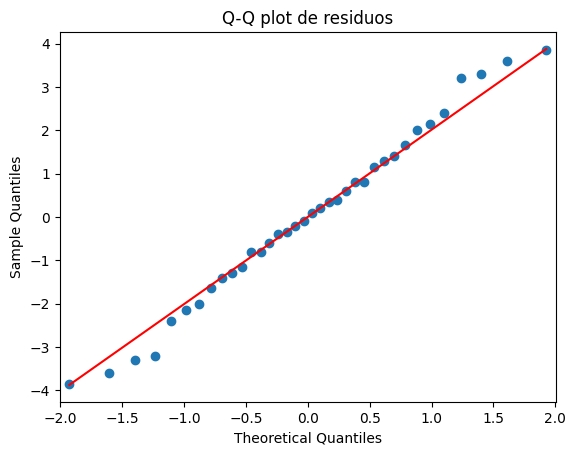

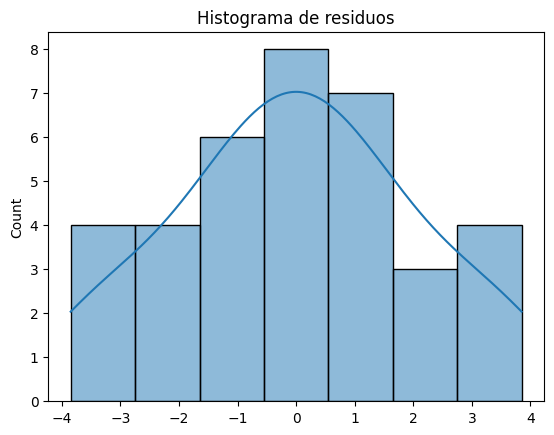

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")
if valor_p_sh > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

valor-p (Shapiro) = 0.7901646675347502
Los residuos siguen una distribución normal


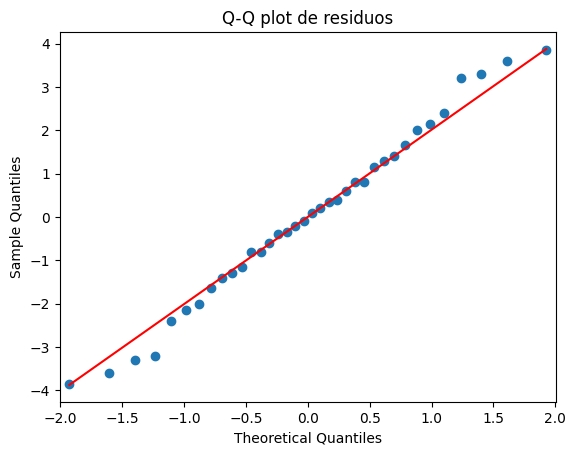

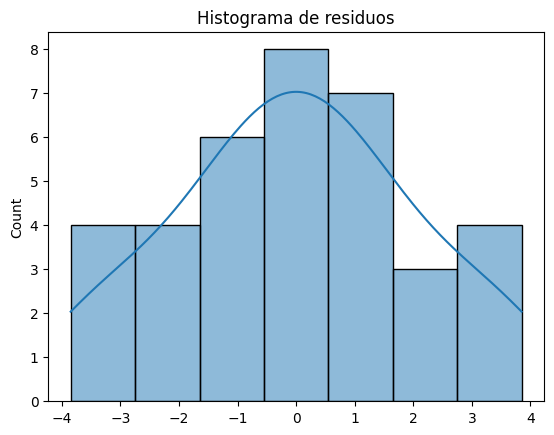

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")
if valor_p_sh > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1      group2    meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
MinuteMaid     Richfood  -0.8417 0.8572  -4.738 3.0547  False
MinuteMaid Sealed_Sweet  -2.3083 0.3259 -6.2047  1.588  False
  Richfood Sealed_Sweet  -1.4667 0.6294  -5.363 2.4297  False
-------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

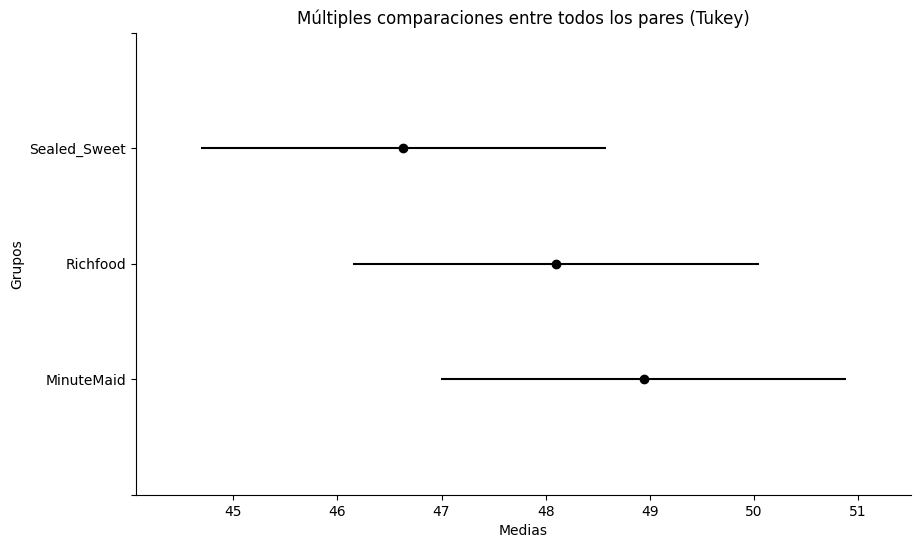

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['medicion'], groups=df['marca'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

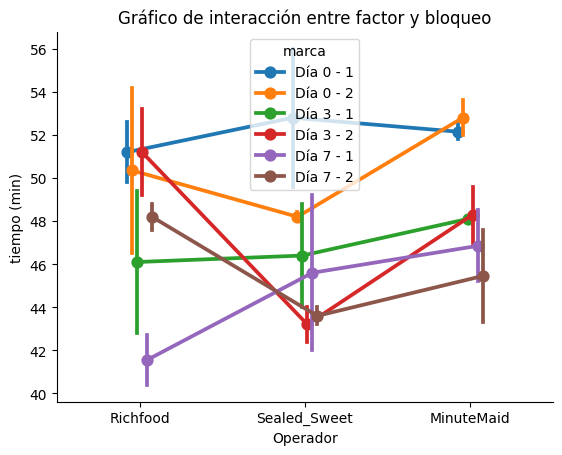

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="marca", y="medicion", hue="dia", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="marca")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

EJERCICIO 14.3

14.3 Se estudió el desempeño de 3 cepas de ratas en
una prueba de laberintos en 2 condiciones ambientales
diferentes. Se registraron las puntuaciones de error de
las 48 ratas

Utilice un nivel de signifi cancia de 0.01 para probar las
hipótesis de que

 a) no hay diferencia en las puntuaciones de error para
ambientes diferentes;

 b) no existe diferencia en las puntuaciones de error
para cepas diferentes;

 c) no hay interacción entre los ambientes y las cepas
de las ratas.

| Ambiente     | Brillante 1 | Brillante 2 | Mezclada 1 | Mezclada 2 | Torpe 1 | Torpe 2 |
|--------------|-------------|-------------|-------------|-------------|---------|---------|
| **Libre**    | 28          | 12          | 33          | 83          | 101     | 94      |
|              | 22          | 23          | 36          | 14          | 33      | 56      |
|              | 25          | 10          | 41          | 76          | 122     | 83      |
|              | 36          | 86          | 22          | 58          | 35      | 23      |
| **Restringido** | 72       | 32          | 60          | 89          | 136     | 120     |
|              | 48          | 93          | 35          | 126         | 38      | 153     |
|              | 25          | 31          | 83          | 110         | 64      | 128     |
|              | 91          | 19          | 99          | 118         | 87      | 140     |

In [ ]:
import pandas as pd
from io import StringIO

data = '''
Ambiente,Brillante 1,Brillante 2,Mezclada 1,Mezclada 2,Torpe 1,Torpe 2
Libre,28,12,33,83,101,94
Libre,22,23,36,14,33,56
Libre,25,10,41,76,122,83
Libre,36,86,22,58,35,23
Restringido,72,32,60,89,136,120
Restringido,48,93,35,126,38,153
Restringido,25,31,83,110,64,128
Restringido,91,19,99,118,87,140
'''
df = pd.read_csv(StringIO(data))
df

,Ambiente,Brillante 1,Brillante 2,Mezclada 1,Mezclada 2,Torpe 1,Torpe 2
0,Libre,28,12,33,83,101,94
1,Libre,22,23,36,14,33,56
2,Libre,25,10,41,76,122,83
3,Libre,36,86,22,58,35,23
4,Restringido,72,32,60,89,136,120
5,Restringido,48,93,35,126,38,153
6,Restringido,25,31,83,110,64,128
7,Restringido,91,19,99,118,87,140


In [ ]:
df_long = df.melt(id_vars=['Ambiente'], var_name='cepa', value_name='puntuacion')

from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols('puntuacion ~ C(Ambiente) * C(cepa)', data=df_long).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Ambiente),14875.520833,1.0,17.262130,0.000191
C(cepa),24695.854167,5.0,5.731605,0.000546
C(Ambiente):C(cepa),5863.354167,5.0,1.360813,0.261929
Residual,31022.750000,36.0,NaN,NaN


valor-p (Shapiro) = 0.3051475909908403
Los residuos siguen una distribución normal


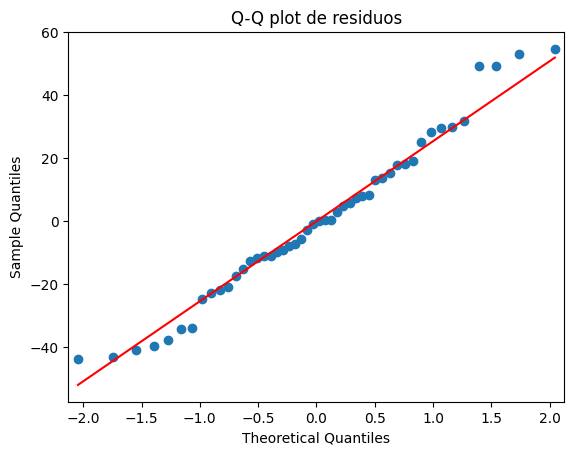

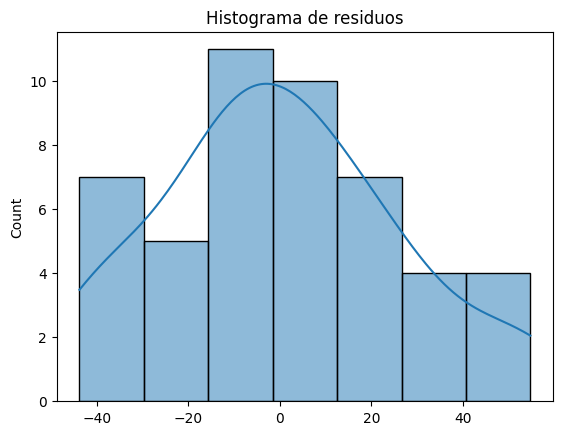

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")
if valor_p_sh > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj   lower    upper   reject
----------------------------------------------------------------
Brillante 1 Brillante 2   -5.125 0.9997 -57.5248  47.2748  False
Brillante 1  Mezclada 1     7.75 0.9977 -44.6498  60.1498  False
Brillante 1  Mezclada 2   40.875 0.2057 -11.5248  93.2748  False
Brillante 1     Torpe 1   33.625 0.4072 -18.7748  86.0248  False
Brillante 1     Torpe 2    56.25  0.029   3.8502 108.6498   True
Brillante 2  Mezclada 1   12.875 0.9766 -39.5248  65.2748  False
Brillante 2  Mezclada 2     46.0 0.1146  -6.3998  98.3998  False
Brillante 2     Torpe 1    38.75 0.2559 -13.6498  91.1498  False
Brillante 2     Torpe 2   61.375 0.0134   8.9752 113.7748   True
 Mezclada 1  Mezclada 2   33.125 0.4239 -19.2748  85.5248  False
 Mezclada 1     Torpe 1   25.875 0.6821 -26.5248  78.2748  False
 Mezclada 1     Torpe 2     48.5 0.0839  -3.8998 100.8998  False
 Mezclada 2     Torpe 1  

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

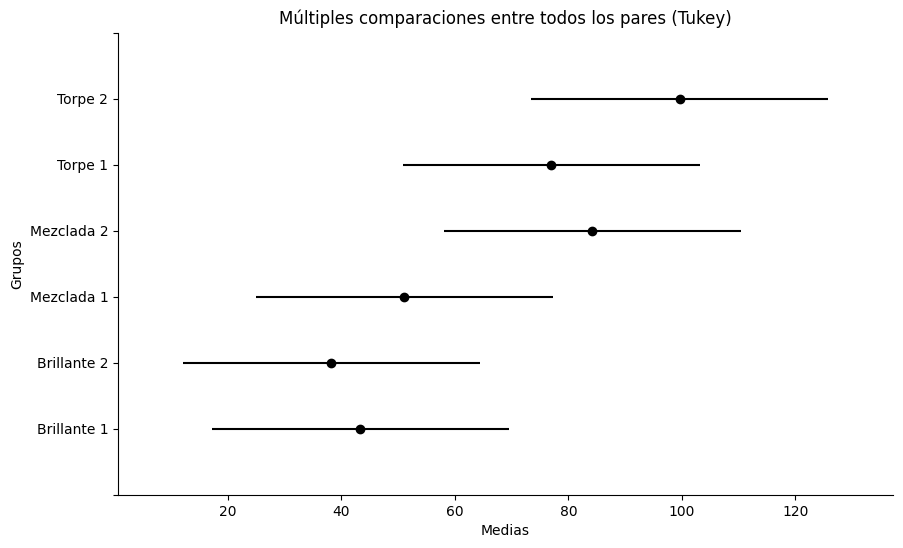

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_long['puntuacion'], groups=df_long['cepa'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

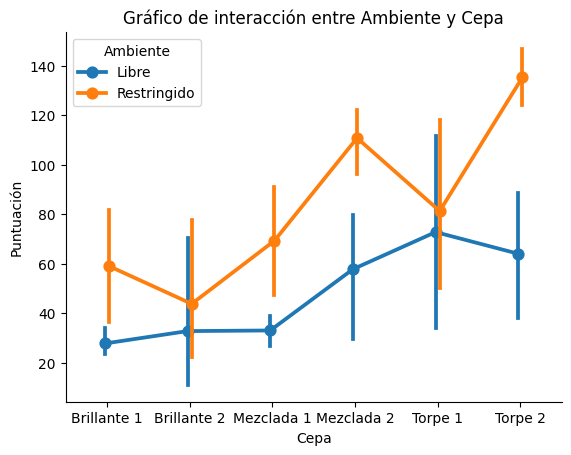

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="cepa", y="puntuacion", hue="Ambiente", data=df_long, dodge=True)
plt.title(f"Gráfico de interacción entre Ambiente y Cepa")
plt.xlabel("Cepa")
plt.ylabel("Puntuación")
plt.legend(title="Ambiente")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

EJERCICIO

En un experimento se estudiaron 2 factores de
un proceso de manufactura de un circuito integrado. El
propósito del experimento es conocer su efecto sobre la
resistividad de las obleas de silicio. Los factores son
la dosis del implante (2 niveles) y la posición de la caldera (3 niveles). El experimento es costoso, por lo que
sólo se hizo una corrida con cada combinación. Los datos son los siguientes.

| Dosis | Posición 1 | Posición 2 | Posición 3 |
|-------|------------|------------|------------|
| 1     | 15.5       | 14.8       | 21.3       |
| 2     | 27.2       | 24.9       | 26.1       |

Se supone que no hay interacción entre esos 2 factores.

 a) Escriba el modelo y explique sus términos.

 b) Elabore la tabla de análisis de varianza.

 c) Explique los 2 grados de libertad del “error”.

 d ) Use una prueba de Tukey para hacer pruebas de
comparaciones múltiples sobre la posición de la
caldera.

Explique qué es lo que muestran los resultados.

In [ ]:
import pandas as pd
from io import StringIO

data = '''
dosis,posicion,valor
1,Posición 1,15.5
1,Posición 2,14.8
1,Posición 3,21.3
2,Posición 1,27.2
2,Posición 2,24.9
2,Posición 3,26.1
'''

df = pd.read_csv(StringIO(data))
df

,dosis,posicion,valor
0,1,Posición 1,15.5
1,1,Posición 2,14.8
2,1,Posición 3,21.3
3,2,Posición 1,27.2
4,2,Posición 2,24.9
5,2,Posición 3,26.1


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols('valor ~ C(dosis) + C(posicion)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(dosis),117.926667,1.0,18.082290,0.051101
C(posicion),15.063333,2.0,1.154868,0.464065
Residual,13.043333,2.0,NaN,NaN


valor-p (Shapiro) = 0.7351982507265403
Los residuos siguen una distribución normal


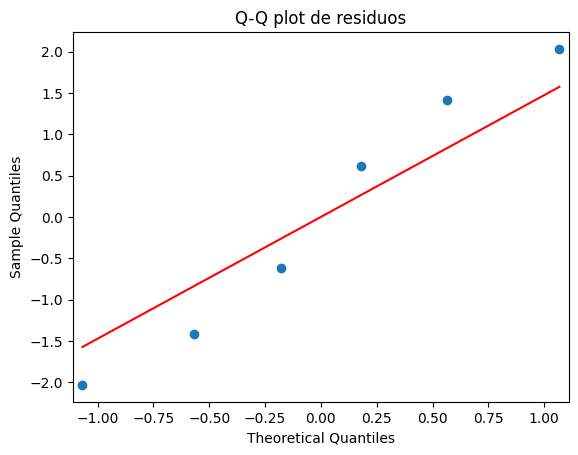

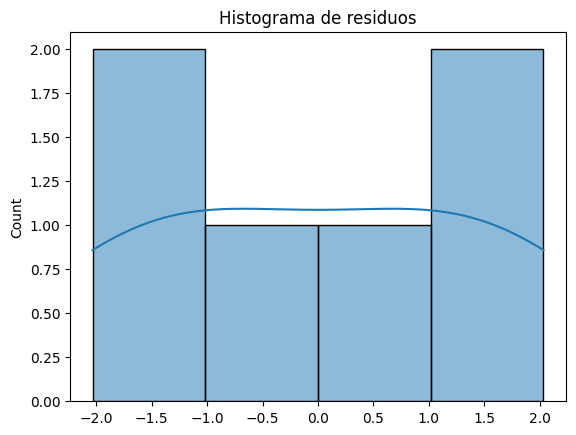

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")
if valor_p_sh > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Posición 1 Posición 2     -1.5 0.9722 -29.1101 26.1101  False
Posición 1 Posición 3     2.35 0.9341 -25.2601 29.9601  False
Posición 2 Posición 3     3.85 0.8384 -23.7601 31.4601  False
-------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

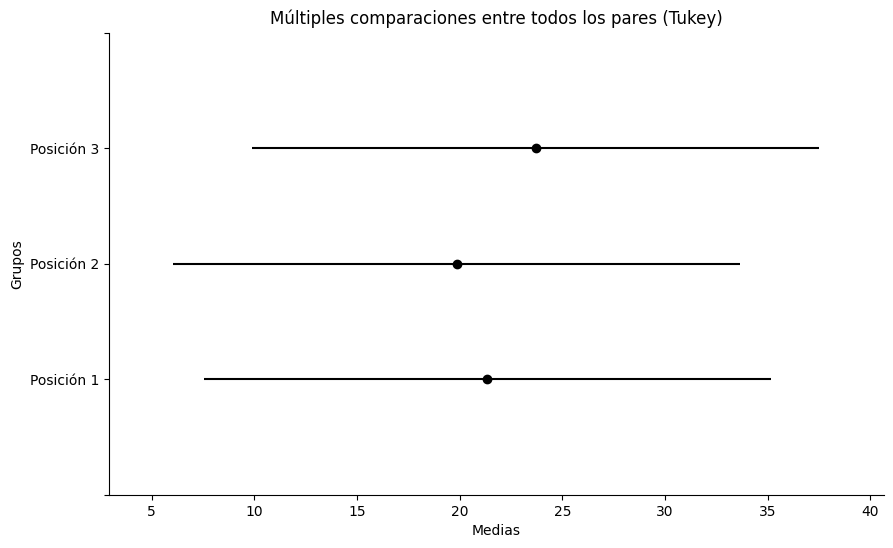

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['valor'], groups=df['posicion'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

EJERCICIO

Un ingeniero está interesado en los efectos de la
velocidad de corte y la geometría de la herramienta sobre las horas de vida de una máquina-herramienta. Se
utilizan 2 velocidades de corte y 2 geometrías distintas.
Se llevan a cabo 3 pruebas experimentales con cada una
de las 4 combinaciones. Los datos son los siguientes:


| Geometría de la herramienta | Baja 1 | Baja 2 | Baja 3 | Alta 1 | Alta 2 | Alta 3 |
|-----------------------------|--------|--------|--------|--------|--------|--------|
| 1                           | 22     | 28     | 20     | 34     | 37     | 29     |
| 2                           | 18     | 15     | 16     | 11     | 10     | 10     |


 a) Calcule la tabla del análisis de varianza con pruebas sobre los efectos principales y de interacción.

 b) Haga comentarios sobre el efecto que tiene la interacción sobre la prueba de la velocidad de corte.

c) Efectúe pruebas secundarias que permitan al ingeniero conocer el verdadero impacto de la velocidad de corte.

 d ) Construya una gráfica que ilustre el efecto de interacción.

In [23]:
import pandas as pd
from io import StringIO
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Cargar los datos
data = """Geometría,Herramienta,Valor
1,Baja 1,22
1,Baja 2,28
1,Baja 3,20
1,Alta 1,34
1,Alta 2,37
1,Alta 3,29
2,Baja 1,18
2,Baja 2,15
2,Baja 3,16
2,Alta 1,11
2,Alta 2,10
2,Alta 3,10
"""

df = pd.read_csv(StringIO(data))

# Extraer columna Velocidad a partir de la columna Herramienta
df['Velocidad'] = df['Herramienta'].str.extract(r'(Baja|Alta)')
df['Velocidad'] = df['Velocidad'].astype('category')
df['Geometría'] = df['Geometría'].astype('category')

# Modelo lineal y tabla ANOVA de dos vías con interacción
modelo_lineal = ols('Valor ~ C(Velocidad) * C(Geometría)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)

# Mostrar tabla ANOVA
print(tabla_anova)
df

                               sum_sq   df          F    PR(>F)
C(Velocidad)                12.000000  1.0   1.321101  0.283595
C(Geometría)               675.000000  1.0  74.311927  0.000025
C(Velocidad):C(Geometría)  192.000000  1.0  21.137615  0.001761
Residual                    72.666667  8.0        NaN       NaN


,Geometría,Herramienta,Valor,Velocidad
0,1,Baja 1,22,Baja
1,1,Baja 2,28,Baja
2,1,Baja 3,20,Baja
3,1,Alta 1,34,Alta
4,1,Alta 2,37,Alta
5,1,Alta 3,29,Alta
6,2,Baja 1,18,Baja
7,2,Baja 2,15,Baja
8,2,Baja 3,16,Baja
9,2,Alta 1,11,Alta


valor-p (Shapiro) = 0.2518
Los residuos siguen una distribución normal


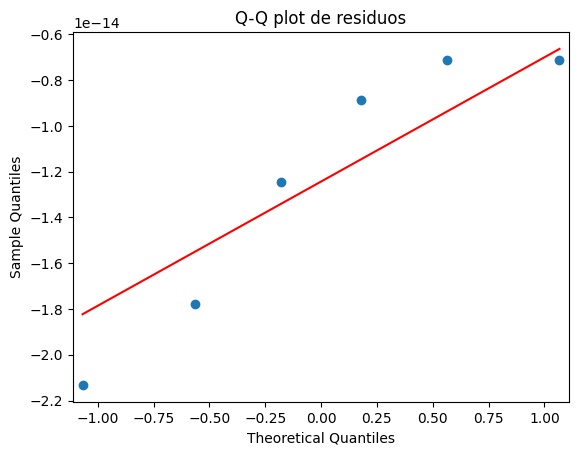

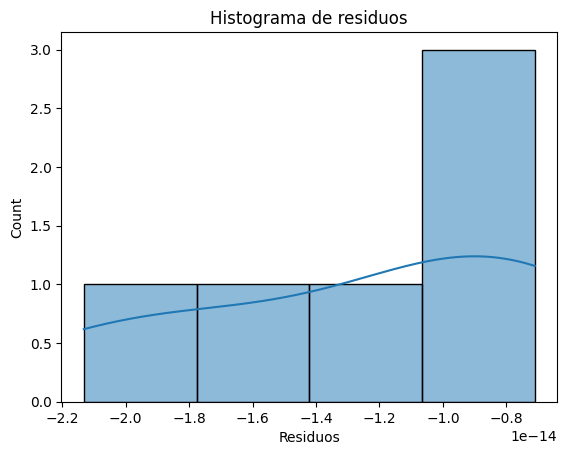

In [24]:
import pandas as pd
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame
data = {
    "dosis": [1, 1, 1, 2, 2, 2],
    "posicion": ["Posición 1", "Posición 2", "Posición 3"] * 2,
    "valor": [15.5, 14.8, 21.3, 27.2, 24.9, 26.1]
}
df = pd.DataFrame(data)

# Modelo lineal (ANOVA de dos vías)
modelo_lineal = ols('valor ~ C(dosis) * C(posicion)', data=df).fit()
residuos = modelo_lineal.resid

# Prueba de normalidad de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh:.4f}")
if valor_p_sh > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")

# Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma de residuos
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.xlabel("Residuos")
plt.show()

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Posición 1 Posición 2     -1.5 0.9722 -29.1101 26.1101  False
Posición 1 Posición 3     2.35 0.9341 -25.2601 29.9601  False
Posición 2 Posición 3     3.85 0.8384 -23.7601 31.4601  False
-------------------------------------------------------------


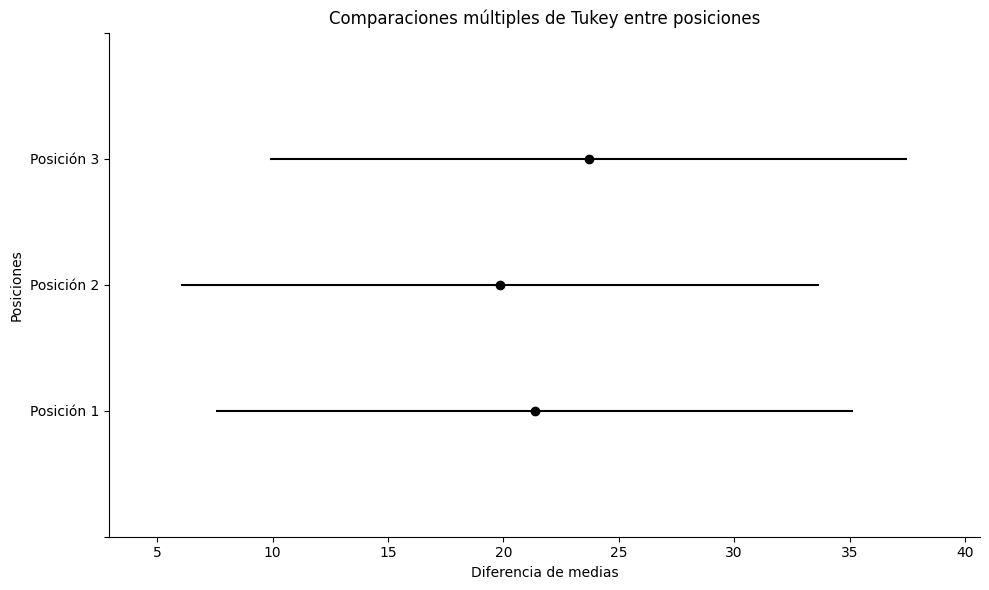

In [25]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Crear el DataFrame con tus datos
data = {
    "dosis": [1, 1, 1, 2, 2, 2],
    "posicion": ["Posición 1", "Posición 2", "Posición 3"] * 2,
    "valor": [15.5, 14.8, 21.3, 27.2, 24.9, 26.1]
}
df = pd.DataFrame(data)

# Prueba de Tukey para comparar posiciones
nivel_de_significancia = 0.05
tukey = pairwise_tukeyhsd(endog=df['valor'], groups=df['posicion'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de comparaciones múltiples
tukey.plot_simultaneous(ylabel="Posiciones", xlabel="Diferencia de medias")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.title("Comparaciones múltiples de Tukey entre posiciones")
plt.tight_layout()
plt.show()

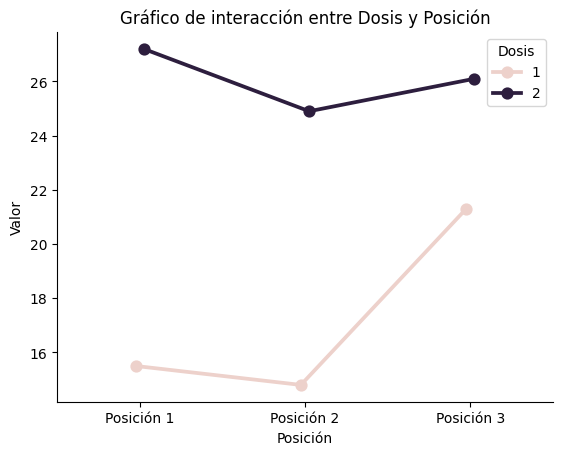

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pointplot(x="posicion", y="valor", hue="dosis", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre Dosis y Posición")
plt.xlabel("Posición")
plt.ylabel("Valor")
plt.legend(title="Dosis")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()